In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Load the cleaned and scaled data generated by preprocess.py
train_data = pd.read_csv('../data/processed/train_cleaned.csv')
test_data = pd.read_csv('../data/processed/test_cleaned.csv')

X_train = train_data.drop(columns=['LUNG_CANCER'])
y_train = train_data['LUNG_CANCER']

X_test = test_data.drop(columns=['LUNG_CANCER'])
y_test = test_data['LUNG_CANCER']

In [2]:
# Initialize and Train the Random Forest Model
# class_weight='balanced' is vital here due to the 270 vs 39 imbalance
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

In [3]:
# Evaluate the model
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.58      0.88      0.70         8
           1       0.98      0.91      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.89      0.82        62
weighted avg       0.93      0.90      0.91        62



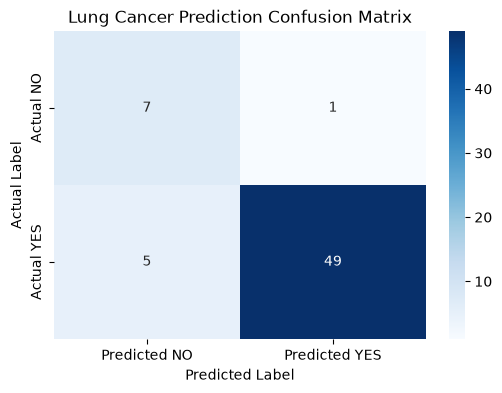

In [4]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted NO', 'Predicted YES'], 
            yticklabels=['Actual NO', 'Actual YES'])
plt.title('Lung Cancer Prediction Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [5]:
# Save the final model for deployment/prediction script
joblib.dump(model, '../models/lung_cancer_rf_model.pkl')
print("Model successfully saved to models/lung_cancer_rf_model.pkl")

Model successfully saved to models/lung_cancer_rf_model.pkl
